In [1]:
import pandas as pd

file_path = r"C:\Users\gouth\OneDrive\Documents\Term-3\software_tools_emerginsg\Assessment_1\maplefreight_delivery_delay_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (6035, 23)


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
0,SHP-103848,Mississauga ON,Edmonton AB,NorthStar Carriers,Standard,General Freight,Bronze,1,376.0,257.1,...,55.0,5.1,6.1,Fog,37.2,0.291,1,146.39,7.55,0
1,SHP-102827,Montreal QC,Winnipeg MB,PrairieLine,Standard,General Freight,Silver,12,159.8,734.1,...,69.0,5.3,4.2,Snow,77.4,0.236,0,155.07,1.17,1
2,SHP-105254,Toronto ON,Hamilton ON,QuebecExpress,Standard,Fragile,Silver,9,423.0,680.8,...,-13.0,1.4,2.8,Rain,36.5,0.344,0,163.44,6.47,0
3,SHP-102719,Montreal QC,Hamilton ON,MapleFreight Fleet,Standard,General Freight,Silver,1,494.1,1292.2,...,-20.0,4.0,14.8,Fog,51.2,0.491,2,NaN,8.03,0
4,SHP-105198,Mississauga ON,Sudbury ON,MapleFreight Fleet,Standard,Refrigerated,Bronze,9,843.5,3327.1,...,28.0,2.9,1.6,Clear,82.7,0.423,1,263.22,13.49,0


In [2]:
print("DATA TYPES AND NON-NULL COUNTS")
df.info()

print("\nMISSING VALUES")
display(
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

print("\nDUPLICATES")
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate shipment IDs:", df["shipment_id"].duplicated().sum())

print("\nTARGET DISTRIBUTION")
print(df["delivered_late"].value_counts(dropna=False))
print(
    (df["delivered_late"].value_counts(normalize=True) * 100)
    .round(2)
    .rename("percentage")
)

DATA TYPES AND NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6035 entries, 0 to 6034
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   shipment_id                6035 non-null   object 
 1   origin_city                6035 non-null   object 
 2   destination_city           6035 non-null   object 
 3   carrier                    6035 non-null   object 
 4   service_level              6035 non-null   object 
 5   goods_type                 6035 non-null   object 
 6   customer_priority_tier     6035 non-null   object 
 7   shipment_month             6035 non-null   int64  
 8   distance_km                6035 non-null   float64
 9   weight_kg                  6035 non-null   float64
 10  num_stops                  6035 non-null   int64  
 11  is_cross_border            6035 non-null   int64  
 12  scheduled_transit_hours    6035 non-null   float64
 13  pickup_delay_minu

,missing_count
fuel_cost_cad,240
driver_experience_years,210
weather_condition,150
traffic_index,121
shipment_id,0
origin_city,0
destination_city,0
customer_priority_tier,0
goods_type,0
service_level,0



DUPLICATES
Duplicate rows: 32
Duplicate shipment IDs: 35

TARGET DISTRIBUTION
delivered_late
0    4793
1    1242
Name: count, dtype: int64
delivered_late
0    79.42
1    20.58
Name: percentage, dtype: float64


In [3]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

print("\nNUMERIC SUMMARY")
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
display(df[numeric_cols].describe().T)

print("\nPOSSIBLE INVALID VALUES")
print("Invalid shipment months:",
      df.loc[~df["shipment_month"].between(1, 12), "shipment_month"].unique())

print("Invalid cross-border values:",
      df.loc[~df["is_cross_border"].isin([0, 1]), "is_cross_border"].unique())

print("Invalid target values:",
      df.loc[~df["delivered_late"].isin([0, 1]), "delivered_late"].unique())

print("Negative distance values:",
      (df["distance_km"] < 0).sum())

print("Negative weight values:",
      (df["weight_kg"] < 0).sum())

print("Non-positive scheduled transit values:",
      (df["scheduled_transit_hours"] <= 0).sum())


--- shipment_id ---
shipment_id
SHP-100905    2
SHP-101906    2
SHP-105215    2
SHP-100018    2
SHP-104137    2
             ..
SHP-101294    1
SHP-104024    1
SHP-105201    1
SHP-103776    1
SHP-101946    1
Name: count, Length: 6000, dtype: int64

--- origin_city ---
origin_city
Toronto ON        1593
Mississauga ON    1019
Montreal QC       1017
Calgary AB         762
Ottawa ON          730
London ON          460
Winnipeg MB        454
Name: count, dtype: int64

--- destination_city ---
destination_city
Sudbury ON        641
Toronto ON        638
Regina SK         634
Winnipeg MB       614
Hamilton ON       604
Quebec City QC    598
Edmonton AB       592
Montreal QC       587
Calgary AB        578
Ottawa ON         549
Name: count, dtype: int64

--- carrier ---
carrier
MapleFreight Fleet    2391
NorthStar Carriers    1164
PrairieLine            932
QuebecExpress          924
Contract Owner-Op      624
Name: count, dtype: int64

--- service_level ---
service_level
Standard    3219
Ex

,count,mean,std,min,25%,50%,75%,max
shipment_month,6035.0,6.543662,3.448260,1.00,4.000,7.000,10.000,12.00
distance_km,6035.0,632.192742,319.246133,80.50,398.600,571.100,804.850,2556.70
weight_kg,6035.0,6928.251135,83755.149685,30.00,496.000,827.100,1286.300,2999300.00
num_stops,6035.0,2.477051,1.707457,0.00,1.000,2.000,4.000,5.00
is_cross_border,6035.0,0.113007,0.316628,0.00,0.000,0.000,0.000,1.00
scheduled_transit_hours,6035.0,10.500388,4.758576,1.00,7.060,9.850,13.175,37.40
pickup_delay_minutes,6035.0,20.367688,30.618617,-20.00,-6.000,18.000,41.000,146.00
driver_experience_years,5825.0,6.497648,4.659277,0.20,3.200,5.400,8.600,35.00
vehicle_age_years,6035.0,5.489461,3.433676,0.10,3.000,4.800,7.200,20.00
traffic_index,5914.0,55.146365,17.592978,5.00,43.300,55.000,67.200,100.00



POSSIBLE INVALID VALUES
Invalid shipment months: []
Invalid cross-border values: []
Invalid target values: []
Negative distance values: 0
Negative weight values: 0
Non-positive scheduled transit values: 0


In [4]:
print("EXACT DUPLICATE ROWS")
print(df.duplicated().sum())

print("\nREPEATED SHIPMENT IDs")
id_counts = df["shipment_id"].value_counts()
repeated_ids = id_counts[id_counts > 1]

print("Number of repeated shipment IDs:", len(repeated_ids))
display(repeated_ids.to_frame("row_count"))

print("\nWEIGHT OUTLIERS")
print("Weights above 10,000 kg:", (df["weight_kg"] > 10000).sum())

display(
    df.nlargest(10, "weight_kg")[
        [
            "shipment_id",
            "weight_kg",
            "goods_type",
            "distance_km",
            "num_stops",
            "delivered_late"
        ]
    ]
)

print("\nSERVICE LEVEL SPELLINGS")
print(df["service_level"].unique())

EXACT DUPLICATE ROWS
32

REPEATED SHIPMENT IDs
Number of repeated shipment IDs: 35


,row_count
shipment_id,
SHP-100905,2
SHP-101906,2
SHP-105215,2
SHP-100018,2
SHP-104137,2
SHP-101239,2
SHP-103022,2
SHP-101174,2
SHP-100037,2



WEIGHT OUTLIERS
Weights above 10,000 kg: 40


,shipment_id,weight_kg,goods_type,distance_km,num_stops,delivered_late
2323,SHP-102944,2999300.0,Hazardous,349.6,4,0
846,SHP-101687,1593600.0,General Freight,552.8,3,0
1525,SHP-102395,1554700.0,General Freight,418.2,1,0
3284,SHP-100634,1408300.0,General Freight,305.2,0,0
4761,SHP-104016,1389500.0,General Freight,577.9,2,0
696,SHP-100641,1332200.0,General Freight,843.1,0,0
4028,SHP-103017,1246100.0,General Freight,194.0,5,0
4876,SHP-104749,1238200.0,Fragile,519.3,1,0
4024,SHP-100891,1227100.0,Refrigerated,639.6,2,1
1030,SHP-102384,1209400.0,General Freight,944.6,4,0



SERVICE LEVEL SPELLINGS
['Standard' 'Express' 'Economy' 'standard' 'economy' 'express']


In [5]:
# Remove only fully identical rows in a new working copy
df_no_exact_dups = df.drop_duplicates().copy()

# Find shipment IDs that still occur more than once
remaining_id_counts = df_no_exact_dups["shipment_id"].value_counts()
conflicting_ids = remaining_id_counts[remaining_id_counts > 1].index

print(
    "Repeated shipment IDs after removing exact duplicates:",
    len(conflicting_ids)
)

display(
    df_no_exact_dups[
        df_no_exact_dups["shipment_id"].isin(conflicting_ids)
    ].sort_values("shipment_id")
)

# Check whether extreme weights become realistic when interpreted as grams
weight_outliers = df_no_exact_dups[
    df_no_exact_dups["weight_kg"] > 10000
].copy()

weight_outliers["weight_if_grams_kg"] = (
    weight_outliers["weight_kg"] / 1000
)

print("\nExtreme weight records:", len(weight_outliers))
print(
    "Corrected-weight range:",
    weight_outliers["weight_if_grams_kg"].min(),
    "to",
    weight_outliers["weight_if_grams_kg"].max(),
    "kg"
)

display(
    weight_outliers[
        ["shipment_id", "weight_kg", "weight_if_grams_kg", "goods_type"]
    ].head(10)
)

Repeated shipment IDs after removing exact duplicates: 3


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
861,SHP-101906,Toronto ON,Edmonton AB,NorthStar Carriers,Express,General Freight,Bronze,7,333.7,1002.7,...,-20.0,10.0,3.8,Storm,27.9,0.320,2,261.21,8.00,0
3030,SHP-101906,Toronto ON,Edmonton AB,NorthStar Carriers,standard,General Freight,Bronze,7,333.7,1002.7,...,-20.0,10.0,3.8,Storm,27.9,0.320,2,261.21,8.00,0
1228,SHP-102476,Toronto ON,Montreal QC,QuebecExpress,Standard,Hazardous,Silver,3,949.0,245.6,...,54.0,3.3,4.7,Storm,66.2,0.295,1,255.48,16.00,1
4033,SHP-102476,Toronto ON,Montreal QC,QuebecExpress,standard,Hazardous,Silver,3,949.0,245.6,...,54.0,3.3,4.7,Storm,66.2,0.295,1,255.48,16.00,1
441,SHP-103022,Mississauga ON,Regina SK,Contract Owner-Op,Standard,General Freight,Bronze,1,404.4,570.1,...,-10.0,7.3,3.5,Snow,64.8,0.430,3,149.40,7.53,0
4375,SHP-103022,Mississauga ON,Regina SK,Contract Owner-Op,standard,General Freight,Bronze,1,404.4,570.1,...,-10.0,7.3,3.5,Snow,64.8,0.430,3,149.40,7.53,0



Extreme weight records: 40
Corrected-weight range: 170.9 to 2999.3 kg


,shipment_id,weight_kg,weight_if_grams_kg,goods_type
666,SHP-102849,1121100.0,1121.1,General Freight
696,SHP-100641,1332200.0,1332.2,General Freight
846,SHP-101687,1593600.0,1593.6,General Freight
865,SHP-105182,555500.0,555.5,Fragile
943,SHP-100519,285200.0,285.2,General Freight
977,SHP-104825,760200.0,760.2,General Freight
998,SHP-102703,362100.0,362.1,General Freight
1030,SHP-102384,1209400.0,1209.4,General Freight
1324,SHP-102735,618400.0,618.4,General Freight
1525,SHP-102395,1554700.0,1554.7,General Freight


In [6]:
print("Conflicting shipment IDs:", len(conflicting_ids))

display(
    df_no_exact_dups[
        df_no_exact_dups["shipment_id"].isin(conflicting_ids)
    ].sort_values("shipment_id")
)

Conflicting shipment IDs: 3


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
861,SHP-101906,Toronto ON,Edmonton AB,NorthStar Carriers,Express,General Freight,Bronze,7,333.7,1002.7,...,-20.0,10.0,3.8,Storm,27.9,0.320,2,261.21,8.00,0
3030,SHP-101906,Toronto ON,Edmonton AB,NorthStar Carriers,standard,General Freight,Bronze,7,333.7,1002.7,...,-20.0,10.0,3.8,Storm,27.9,0.320,2,261.21,8.00,0
1228,SHP-102476,Toronto ON,Montreal QC,QuebecExpress,Standard,Hazardous,Silver,3,949.0,245.6,...,54.0,3.3,4.7,Storm,66.2,0.295,1,255.48,16.00,1
4033,SHP-102476,Toronto ON,Montreal QC,QuebecExpress,standard,Hazardous,Silver,3,949.0,245.6,...,54.0,3.3,4.7,Storm,66.2,0.295,1,255.48,16.00,1
441,SHP-103022,Mississauga ON,Regina SK,Contract Owner-Op,Standard,General Freight,Bronze,1,404.4,570.1,...,-10.0,7.3,3.5,Snow,64.8,0.430,3,149.40,7.53,0
4375,SHP-103022,Mississauga ON,Regina SK,Contract Owner-Op,standard,General Freight,Bronze,1,404.4,570.1,...,-10.0,7.3,3.5,Snow,64.8,0.430,3,149.40,7.53,0


In [7]:
# Make a separate copy; keep the original df unchanged
df_clean = df.copy()

# Remove leading/trailing spaces from text columns
text_cols = df_clean.select_dtypes(include="object").columns

for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

# Standardize service-level capitalization
df_clean["service_level"] = df_clean["service_level"].str.title()

# Convert incorrectly recorded gram values to kilograms
weight_error_mask = df_clean["weight_kg"] > 10000
df_clean.loc[weight_error_mask, "weight_kg"] = (
    df_clean.loc[weight_error_mask, "weight_kg"] / 1000
)

# Remove duplicates after standardizing text
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
rows_after = len(df_clean)

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
print("Duplicate rows removed:", rows_before - rows_after)
print("Unique shipment IDs:", df_clean["shipment_id"].nunique())
print("Remaining missing values:", df_clean.isna().sum().sum())
print("Remaining extreme weights:", (df_clean["weight_kg"] > 10000).sum())

print("\nService levels after standardization:")
print(df_clean["service_level"].value_counts())

Rows before cleaning: 6035
Rows after cleaning: 6001
Duplicate rows removed: 34
Unique shipment IDs: 6000
Remaining missing values: 720
Remaining extreme weights: 0

Service levels after standardization:
service_level
Standard    3276
Express     1460
Economy     1265
Name: count, dtype: int64


In [8]:
clean_path = r"C:\Users\gouth\OneDrive\Documents\Term-3\software_tools_emerginsg\Assessment_1\maplefreight_delivery_delay_dataset_cleaned.csv"

df_clean.to_csv(clean_path, index=False)

print("Cleaned dataset saved to:", clean_path)

Cleaned dataset saved to: C:\Users\gouth\OneDrive\Documents\Term-3\software_tools_emerginsg\Assessment_1\maplefreight_delivery_delay_dataset_cleaned.csv


In [9]:
remaining_duplicate_rows = df_clean[
    df_clean["shipment_id"].duplicated(keep=False)
].sort_values("shipment_id")

print("Remaining duplicate rows:", len(remaining_duplicate_rows))
print(
    "Remaining duplicated shipment IDs:",
    remaining_duplicate_rows["shipment_id"].unique()
)

display(remaining_duplicate_rows.T)

Remaining duplicate rows: 2
Remaining duplicated shipment IDs: ['SHP-101906']


,861,3030
shipment_id,SHP-101906,SHP-101906
origin_city,Toronto ON,Toronto ON
destination_city,Edmonton AB,Edmonton AB
carrier,NorthStar Carriers,NorthStar Carriers
service_level,Express,Standard
goods_type,General Freight,General Freight
customer_priority_tier,Bronze,Bronze
shipment_month,7,7
distance_km,333.7,333.7
weight_kg,1002.7,1002.7


In [10]:
conflicting_shipment_id = "SHP-101906"

# Keep the first record for the conflicting shipment ID
df_clean = df_clean.drop_duplicates(
    subset="shipment_id",
    keep="first"
).copy()

print("Cleaned dataset shape:", df_clean.shape)
print("Unique shipment IDs:", df_clean["shipment_id"].nunique())
print(
    "Remaining duplicated shipment IDs:",
    df_clean["shipment_id"].duplicated().sum()
)

# Save the updated cleaned dataset
df_clean.to_csv(clean_path, index=False)

Cleaned dataset shape: (6000, 23)
Unique shipment IDs: 6000
Remaining duplicated shipment IDs: 0


 ## Exploratory Data Analysis

Missing-value summary:


,missing_count
fuel_cost_cad,240
driver_experience_years,210
weather_condition,150
traffic_index,120


Delivery outcome distribution:


,shipment_count
delivered_late,
0,4766
1,1234


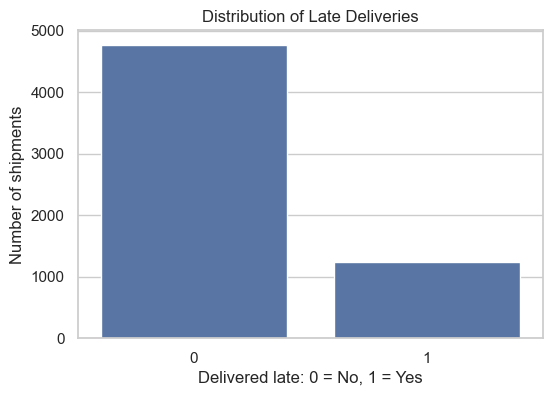


Late-delivery rate by carrier:


,count,late_rate,late_rate_percent
carrier,,,
Contract Owner-Op,622,0.360129,36.01
PrairieLine,927,0.264293,26.43
QuebecExpress,916,0.224891,22.49
NorthStar Carriers,1157,0.219533,21.95
MapleFreight Fleet,2378,0.128259,12.83



Late-delivery rate by service_level:


,count,late_rate,late_rate_percent
service_level,,,
Economy,1265,0.265613,26.56
Standard,3275,0.207023,20.70
Express,1460,0.150685,15.07



Late-delivery rate by goods_type:


...

,count,late_rate,late_rate_percent
weather_condition,,,
Storm,282,0.464539,46.45
Snow,865,0.336416,33.64
Fog,419,0.210024,21.00
Rain,1326,0.207391,20.74
Clear,2958,0.140636,14.06



Late-delivery rate by customer_priority_tier:


,count,late_rate,late_rate_percent
customer_priority_tier,,,
Gold,1163,0.207223,20.72
Bronze,2079,0.206349,20.63
Silver,2758,0.204496,20.45



Late-delivery rate by is_cross_border:


,count,late_rate,late_rate_percent
is_cross_border,,,
1,675,0.244444,24.44
0,5325,0.200751,20.08


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Missing-value summary
missing_summary = (
    df_clean.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_summary = missing_summary[missing_summary["missing_count"] > 0]

print("Missing-value summary:")
display(missing_summary)

# Target distribution
target_counts = df_clean["delivered_late"].value_counts().sort_index()

print("Delivery outcome distribution:")
display(target_counts.to_frame("shipment_count"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="delivered_late")
plt.title("Distribution of Late Deliveries")
plt.xlabel("Delivered late: 0 = No, 1 = Yes")
plt.ylabel("Number of shipments")
plt.show()

# Late-delivery rates by important categories
def late_rate_table(column):
    result = (
        df_clean.groupby(column)["delivered_late"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "late_rate"})
    )
    result["late_rate_percent"] = (result["late_rate"] * 100).round(2)
    return result.sort_values("late_rate", ascending=False)

for column in [
    "carrier",
    "service_level",
    "goods_type",
    "weather_condition",
    "customer_priority_tier",
    "is_cross_border"
]:
    print(f"\nLate-delivery rate by {column}:")
    display(late_rate_table(column))

In [12]:
numeric_eda_cols = [
    "distance_km",
    "weight_kg",
    "num_stops",
    "scheduled_transit_hours",
    "pickup_delay_minutes",
    "driver_experience_years",
    "vehicle_age_years",
    "traffic_index",
    "route_congestion_score",
    "prior_late_deliveries_30d",
    "fuel_cost_cad"
]

numeric_comparison = (
    df_clean.groupby("delivered_late")[numeric_eda_cols]
    .mean()
    .T
    .rename(columns={
        0: "On-time average",
        1: "Late average"
    })
)

numeric_comparison["Difference"] = (
    numeric_comparison["Late average"]
    - numeric_comparison["On-time average"]
)

display(numeric_comparison.sort_values("Difference", ascending=False))

delivered_late,On-time average,Late average,Difference
distance_km,602.085439,748.348055,146.262617
weight_kg,944.988103,988.111912,43.123809
pickup_delay_minutes,18.402854,27.889789,9.486936
traffic_index,53.659469,60.872442,7.212974
scheduled_transit_hours,9.990260,12.458290,2.468030
fuel_cost_cad,180.329641,181.545210,1.215569
num_stops,2.340747,2.993517,0.652770
vehicle_age_years,5.383634,5.916937,0.533303
prior_late_deliveries_30d,1.242132,1.547812,0.305680
route_congestion_score,0.439975,0.487919,0.047944


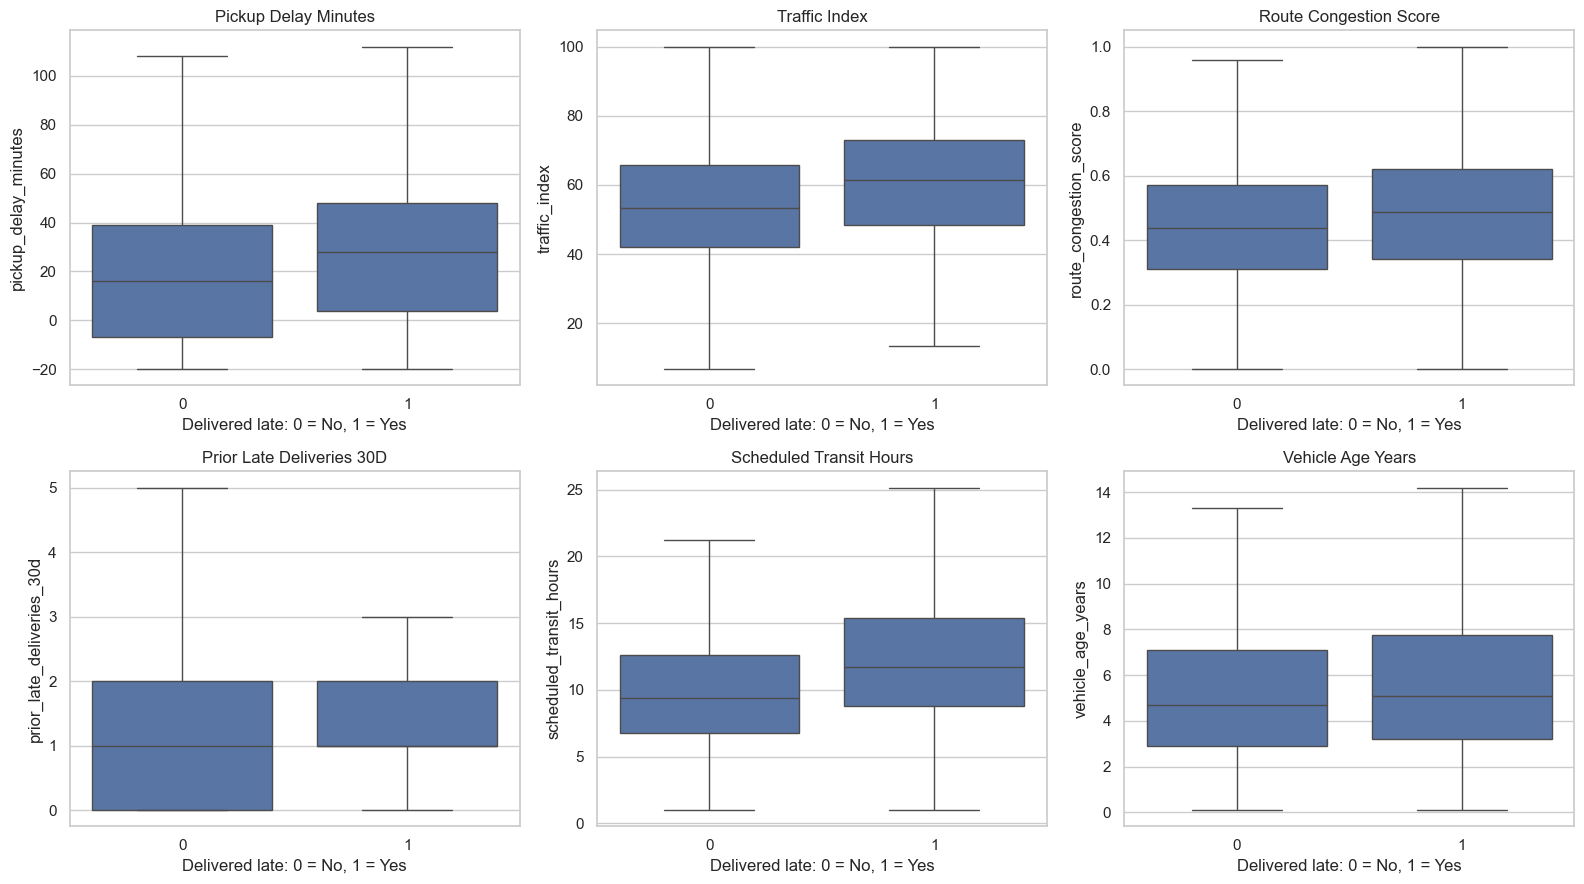

In [13]:
plot_cols = [
    "pickup_delay_minutes",
    "traffic_index",
    "route_congestion_score",
    "prior_late_deliveries_30d",
    "scheduled_transit_hours",
    "vehicle_age_years"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, column in zip(axes.flatten(), plot_cols):
    sns.boxplot(
        data=df_clean,
        x="delivered_late",
        y=column,
        showfliers=False,
        ax=ax
    )
    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel("Delivered late: 0 = No, 1 = Yes")

plt.tight_layout()
plt.show()

### EDA findings

The strongest numerical differences between late and on-time shipments were distance, pickup delay, traffic index, scheduled transit time, number of stops, and route congestion. Late shipments travelled farther, experienced more pickup delay and congestion, and were assigned to routes with more stops. Late shipments also involved slightly older vehicles, more prior late deliveries, and less experienced drivers.

Categorical analysis showed that weather and carrier were especially important. Storm and snow conditions had much higher late-delivery rates than clear weather. Contract Owner-Op had the highest carrier late rate, while MapleFreight Fleet had the lowest. Economy shipments were late more often than Standard and Express shipments.

These are associations rather than proof of causation. The predictive model will evaluate their combined effect while handling missing values and class imbalance.

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split

model_df = df_clean.copy()

# Feature engineering
model_df["distance_per_scheduled_hour"] = (
    model_df["distance_km"]
    / model_df["scheduled_transit_hours"]
)

model_df["pickup_delay_ratio"] = (
    model_df["pickup_delay_minutes"]
    / (model_df["scheduled_transit_hours"] * 60)
)

model_df["traffic_congestion_interaction"] = (
    model_df["traffic_index"]
    * model_df["route_congestion_score"]
)

model_df["route_complexity"] = (
    model_df["num_stops"]
    + model_df["is_cross_border"]
)

# Cyclical representation of pickup month
model_df["month_sin"] = np.sin(
    2 * np.pi * model_df["shipment_month"] / 12
)

model_df["month_cos"] = np.cos(
    2 * np.pi * model_df["shipment_month"] / 12
)

# Remove identifiers, target, and post-delivery information
X = model_df.drop(
    columns=[
        "shipment_id",
        "actual_transit_hours",
        "delivered_late"
    ]
)

y = model_df["delivered_late"]

# Stratified split preserves the late-delivery percentage
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Feature matrix shape:", X.shape)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training late rate:", round(y_train.mean(), 4))
print("Testing late rate:", round(y_test.mean(), 4))

Feature matrix shape: (6000, 26)
Training rows: 4800
Testing rows: 1200
Training late rate: 0.2056
Testing late rate: 0.2058


## Data Preparation and Baseline Models

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {model_name} =====")
    print("Accuracy:", round(accuracy_score(y_test, predictions), 4))
    print("Precision:", round(precision_score(y_test, predictions, zero_division=0), 4))
    print("Recall:", round(recall_score(y_test, predictions, zero_division=0), 4))
    print("F1 score:", round(f1_score(y_test, predictions, zero_division=0), 4))
    print("Average precision:", round(average_precision_score(y_test, probabilities), 4))
    print("\nClassification report:")
    print(classification_report(y_test, predictions, zero_division=0))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, predictions))

# Majority-class baseline
majority_baseline = DummyClassifier(strategy="most_frequent")
majority_baseline.fit(X_train, y_train)

evaluate_model(
    majority_baseline,
    X_test,
    y_test,
    "Majority-Class Baseline"
)

# Interpretable Logistic Regression reference model
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

evaluate_model(
    logistic_model,
    X_test,
    y_test,
    "Balanced Logistic Regression"
)


===== Majority-Class Baseline =====
Accuracy: 0.7942
Precision: 0.0
Recall: 0.0
F1 score: 0.0
Average precision: 0.2058

Classification report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.89       953
           1       0.00      0.00      0.00       247

    accuracy                           0.79      1200
   macro avg       0.40      0.50      0.44      1200
weighted avg       0.63      0.79      0.70      1200

Confusion matrix:
[[953   0]
 [247   0]]

===== Balanced Logistic Regression =====
Accuracy: 0.7467
Precision: 0.4317
Recall: 0.7287
F1 score: 0.5422
Average precision: 0.605

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82       953
           1       0.43      0.73      0.54       247

    accuracy                           0.75      1200
   macro avg       0.67      0.74      0.68      1200
weighted avg       0.82      0.75      0.77      1200

Co

In [16]:
from catboost import CatBoostClassifier

# Prepare copies for CatBoost
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

# CatBoost requires categorical missing values to be represented as text
for column in categorical_features:
    X_train_cb[column] = (
        X_train_cb[column]
        .fillna("Missing")
        .astype(str)
    )
    X_test_cb[column] = (
        X_test_cb[column]
        .fillna("Missing")
        .astype(str)
    )

catboost_model = CatBoostClassifier(
    iterations=600,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False,
    allow_writing_files=False
)

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features
)

evaluate_model(
    catboost_model,
    X_test_cb,
    y_test,
    "Balanced CatBoost"
)


===== Balanced CatBoost =====
Accuracy: 0.7958
Precision: 0.5035
Recall: 0.587
F1 score: 0.5421
Average precision: 0.5606

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       953
           1       0.50      0.59      0.54       247

    accuracy                           0.80      1200
   macro avg       0.70      0.72      0.71      1200
weighted avg       0.81      0.80      0.80      1200

Confusion matrix:
[[810 143]
 [102 145]]


In [17]:
from sklearn.metrics import fbeta_score

logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]
catboost_probabilities = catboost_model.predict_proba(X_test_cb)[:, 1]

def threshold_analysis(y_true, probabilities, model_name):
    rows = []

    for threshold in np.arange(0.10, 0.81, 0.01):
        predictions = (probabilities >= threshold).astype(int)

        rows.append({
            "threshold": round(threshold, 2),
            "precision": precision_score(
                y_true, predictions, zero_division=0
            ),
            "recall": recall_score(
                y_true, predictions, zero_division=0
            ),
            "f1": f1_score(
                y_true, predictions, zero_division=0
            ),
            "f2": fbeta_score(
                y_true, predictions, beta=2, zero_division=0
            )
        })

    results = pd.DataFrame(rows)

    print(f"\nBest thresholds for {model_name}:")
    display(
        results.sort_values("f2", ascending=False).head(10)
    )

    return results

logistic_threshold_results = threshold_analysis(
    y_test,
    logistic_probabilities,
    "Logistic Regression"
)

catboost_threshold_results = threshold_analysis(
    y_test,
    catboost_probabilities,
    "CatBoost"
)


Best thresholds for Logistic Regression:


,threshold,precision,recall,f1,f2
24,0.34,0.356322,0.878543,0.507009,0.679399
23,0.33,0.350962,0.886640,0.502870,0.679280
21,0.31,0.336874,0.898785,0.490066,0.673953
26,0.36,0.361775,0.858300,0.509004,0.673443
22,0.32,0.340557,0.890688,0.492721,0.673195
20,0.30,0.330871,0.906883,0.484848,0.672673
25,0.35,0.357383,0.862348,0.505338,0.672348
19,0.29,0.324713,0.914980,0.479321,0.671021
27,0.37,0.364111,0.846154,0.509135,0.669014
18,0.28,0.319718,0.919028,0.474399,0.668433



Best thresholds for CatBoost:


,threshold,precision,recall,f1,f2
16,0.26,0.380074,0.834008,0.522180,0.673203
18,0.28,0.388781,0.813765,0.526178,0.667774
15,0.25,0.371171,0.834008,0.513716,0.667531
19,0.29,0.395626,0.805668,0.530667,0.667337
20,0.30,0.402041,0.797571,0.534600,0.666441
17,0.27,0.381132,0.817814,0.519949,0.665349
21,0.31,0.405405,0.789474,0.535714,0.663717
14,0.24,0.360000,0.838057,0.503650,0.662188
8,0.18,0.326837,0.882591,0.477024,0.658610
22,0.32,0.407643,0.777328,0.534819,0.657985


In [18]:
FINAL_THRESHOLD = 0.31

final_probabilities = catboost_model.predict_proba(X_test_cb)[:, 1]
final_predictions = (
    final_probabilities >= FINAL_THRESHOLD
).astype(int)

print("Final threshold:", FINAL_THRESHOLD)
print("Accuracy:", round(
    accuracy_score(y_test, final_predictions), 4
))
print("Precision:", round(
    precision_score(y_test, final_predictions, zero_division=0), 4
))
print("Recall:", round(
    recall_score(y_test, final_predictions, zero_division=0), 4
))
print("F1 score:", round(
    f1_score(y_test, final_predictions, zero_division=0), 4
))

print("\nFinal confusion matrix:")
print(confusion_matrix(y_test, final_predictions))

print("\nFinal classification report:")
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["On time", "Late"],
        zero_division=0
    )
)

Final threshold: 0.31
Accuracy: 0.7183
Precision: 0.4054
Recall: 0.7895
F1 score: 0.5357

Final confusion matrix:
[[667 286]
 [ 52 195]]

Final classification report:
              precision    recall  f1-score   support

     On time       0.93      0.70      0.80       953
        Late       0.41      0.79      0.54       247

    accuracy                           0.72      1200
   macro avg       0.67      0.74      0.67      1200
weighted avg       0.82      0.72      0.74      1200



In [19]:
from catboost import Pool

train_pool = Pool(
    X_train_cb,
    y_train,
    cat_features=categorical_features
)

feature_importance_values = catboost_model.get_feature_importance(
    train_pool,
    type="FeatureImportance"
)

feature_importance_df = pd.DataFrame({
    "feature": X_train_cb.columns,
    "importance": feature_importance_values
}).sort_values(
    "importance",
    ascending=False
)

print("Top model features:")
display(feature_importance_df.head(15))

Top model features:


,feature,importance
15,weather_condition,7.321922
16,traffic_index,7.169199
2,carrier,6.769929
11,scheduled_transit_hours,6.580960
14,vehicle_age_years,5.786689
13,driver_experience_years,5.426901
19,fuel_cost_cad,5.381128
17,route_congestion_score,4.681480
12,pickup_delay_minutes,4.614059
20,distance_per_scheduled_hour,4.552118


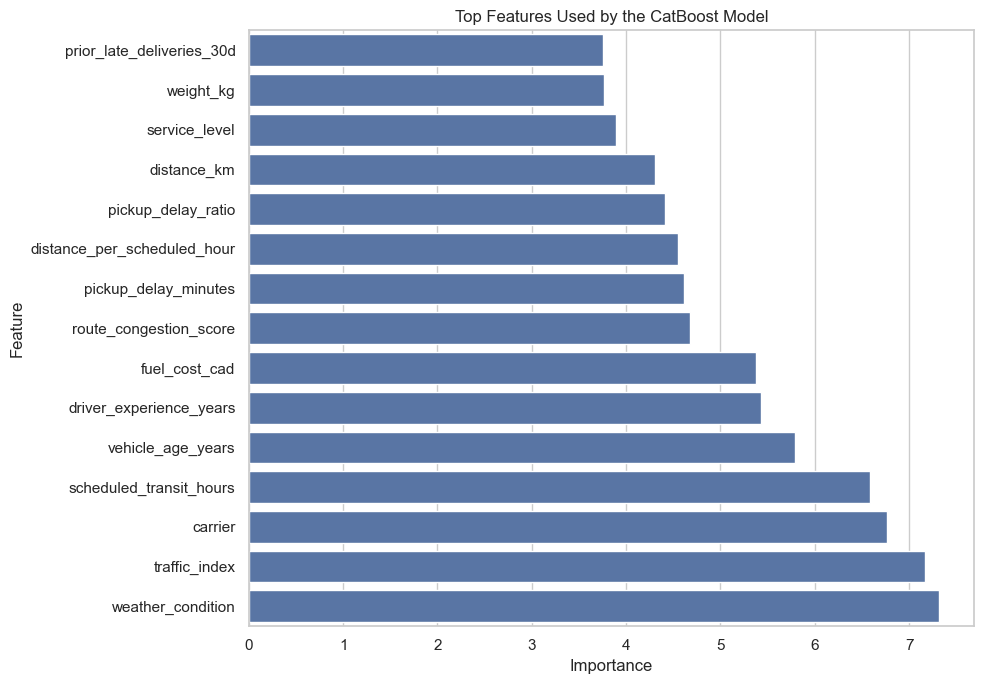

In [20]:
top_features = feature_importance_df.head(15).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top Features Used by the CatBoost Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Model explainability findings

The CatBoost model relied most heavily on weather condition, traffic index, carrier, scheduled transit hours, vehicle age, and driver experience. This agrees with the exploratory analysis, where storms, congestion, longer routes, and weaker carrier performance were associated with higher late-delivery rates.

The engineered features also contributed to predictions. In particular, distance relative to the scheduled transit time and pickup delay relative to the promised window helped the model represent operational pressure more realistically than the raw variables alone.

In [21]:
# Generate SHAP explanations for the test set
test_pool = Pool(
    X_test_cb,
    y_test,
    cat_features=categorical_features
)

shap_values = catboost_model.get_feature_importance(
    test_pool,
    type="ShapValues"
)

# Last column is the base value; remaining columns are feature contributions
shap_feature_values = shap_values[:, :-1]

# Find the highest-risk test shipment
test_risk_scores = catboost_model.predict_proba(X_test_cb)[:, 1]
highest_risk_position = np.argmax(test_risk_scores)

highest_risk_shipment_id = model_df.loc[
    X_test.index[highest_risk_position],
    "shipment_id"
]

print("Highest-risk shipment:", highest_risk_shipment_id)
print(
    "Predicted late-delivery risk:",
    round(test_risk_scores[highest_risk_position], 4)
)

individual_explanation = pd.DataFrame({
    "feature": X_test_cb.columns,
    "value": X_test_cb.iloc[highest_risk_position].values,
    "shap_value": shap_feature_values[highest_risk_position]
})

individual_explanation["direction"] = np.where(
    individual_explanation["shap_value"] > 0,
    "Increases late risk",
    "Reduces late risk"
)

individual_explanation["absolute_impact"] = (
    individual_explanation["shap_value"].abs()
)

display(
    individual_explanation
    .sort_values("absolute_impact", ascending=False)
    .head(10)
)

Highest-risk shipment: SHP-103230
Predicted late-delivery risk: 0.9793


,feature,value,shap_value,direction,absolute_impact
2,carrier,Contract Owner-Op,1.039002,Increases late risk,1.039002
15,weather_condition,Snow,0.909515,Increases late risk,0.909515
13,driver_experience_years,2.1,0.533086,Increases late risk,0.533086
11,scheduled_transit_hours,13.83,0.368289,Increases late risk,0.368289
18,prior_late_deliveries_30d,3,0.351170,Increases late risk,0.351170
12,pickup_delay_minutes,37.0,0.297224,Increases late risk,0.297224
10,is_cross_border,1,0.286408,Increases late risk,0.286408
23,route_complexity,4,0.262827,Increases late risk,0.262827
22,traffic_congestion_interaction,33.1194,0.184797,Increases late risk,0.184797
21,pickup_delay_ratio,0.044589,0.154003,Increases late risk,0.154003


## Intervention-Aware Risk Recommendations

For high-risk shipments, the system tests operational scenarios such as recovering pickup delay, rerouting around congestion, reducing route stops, assigning a more experienced driver, or reassigning the carrier. The predicted risk reduction is used to recommend the most promising action. These are model-based what-if simulations and should be validated operationally.

In [22]:
# Keep the exact feature order used during CatBoost training
model_columns = X_train_cb.columns.tolist()

def engineer_raw_features(raw_data):
    data = raw_data.copy()

    data["distance_per_scheduled_hour"] = (
        data["distance_km"]
        / data["scheduled_transit_hours"]
    )

    data["pickup_delay_ratio"] = (
        data["pickup_delay_minutes"]
        / (data["scheduled_transit_hours"] * 60)
    )

    data["traffic_congestion_interaction"] = (
        data["traffic_index"]
        * data["route_congestion_score"]
    )

    data["route_complexity"] = (
        data["num_stops"]
        + data["is_cross_border"]
    )

    data["month_sin"] = np.sin(
        2 * np.pi * data["shipment_month"] / 12
    )

    data["month_cos"] = np.cos(
        2 * np.pi * data["shipment_month"] / 12
    )

    data = data.drop(
        columns=[
            "shipment_id",
            "actual_transit_hours",
            "delivered_late"
        ],
        errors="ignore"
    )

    return data.reindex(columns=model_columns)


def prepare_for_catboost(raw_data):
    prepared = engineer_raw_features(raw_data)

    for column in categorical_features:
        prepared[column] = (
            prepared[column]
            .fillna("Missing")
            .astype(str)
        )

    return prepared


def predict_risk(raw_data):
    prepared = prepare_for_catboost(raw_data)
    return catboost_model.predict_proba(prepared)[:, 1]

In [23]:
highest_risk_index = X_test.index[highest_risk_position]

high_risk_row = df_clean.loc[[highest_risk_index]].copy()

current_risk = float(predict_risk(high_risk_row)[0])

# Identify the historically best-performing carrier
best_carrier = (
    df_clean.groupby("carrier")["delivered_late"]
    .mean()
    .idxmin()
)

row_values = high_risk_row.iloc[0]

current_pickup_delay = float(row_values["pickup_delay_minutes"])
current_traffic = float(row_values["traffic_index"])
current_congestion = float(row_values["route_congestion_score"])
current_stops = int(row_values["num_stops"])
current_experience = row_values["driver_experience_years"]

if pd.isna(current_experience):
    current_experience = 0

interventions = {
    "Current situation": {},
    "Recover 15 minutes of pickup delay": {
        "pickup_delay_minutes": max(current_pickup_delay - 15, 0)
    },
    "Reroute to reduce traffic": {
        "traffic_index": max(current_traffic - 15, 0)
    },
    "Reduce route congestion": {
        "route_congestion_score": max(current_congestion - 0.10, 0)
    },
    "Remove one route stop": {
        "num_stops": max(current_stops - 1, 0)
    },
    "Assign a more experienced driver": {
        "driver_experience_years": max(current_experience, 8.0)
    },
    f"Reassign to {best_carrier}": {
        "carrier": best_carrier
    }
}

scenario_results = []

for scenario_name, changes in interventions.items():
    scenario_row = high_risk_row.copy()

    for column, value in changes.items():
        scenario_row.loc[:, column] = value

    scenario_risk = float(predict_risk(scenario_row)[0])

    scenario_results.append({
        "scenario": scenario_name,
        "predicted_risk": round(scenario_risk, 4),
        "risk_reduction": round(current_risk - scenario_risk, 4)
    })

intervention_results = (
    pd.DataFrame(scenario_results)
    .sort_values("predicted_risk")
)

display(intervention_results)

,scenario,predicted_risk,risk_reduction
6,Reassign to MapleFreight Fleet,0.8550,0.1243
5,Assign a more experienced driver,0.9463,0.0331
4,Remove one route stop,0.9671,0.0123
2,Reroute to reduce traffic,0.9700,0.0094
1,Recover 15 minutes of pickup delay,0.9759,0.0034
3,Reduce route congestion,0.9785,0.0009
0,Current situation,0.9793,0.0000


### Intervention simulation finding

For shipment SHP-103230, reassigning the shipment to MapleFreight Fleet produced the largest simulated risk reduction, lowering predicted risk from 97.93% to 85.50%. Assigning a more experienced driver was the second-best intervention.

The shipment remained high risk under every simulated scenario, so the recommended action is escalation rather than assuming that one intervention will completely eliminate the risk. These results are model-based what-if simulations and are not causal guarantees.

In [24]:
best_carrier = (
    df_clean.groupby("carrier")["delivered_late"]
    .mean()
    .idxmin()
)

traffic_median = df_clean["traffic_index"].median()
congestion_median = df_clean["route_congestion_score"].median()


def simulate_interventions_for_row(raw_row):
    row_values = raw_row.iloc[0]

    current_risk = float(predict_risk(raw_row)[0])

    pickup_delay = row_values["pickup_delay_minutes"]
    traffic = row_values["traffic_index"]
    congestion = row_values["route_congestion_score"]
    stops = row_values["num_stops"]
    experience = row_values["driver_experience_years"]

    pickup_delay = 0 if pd.isna(pickup_delay) else float(pickup_delay)
    traffic = traffic_median if pd.isna(traffic) else float(traffic)
    congestion = (
        congestion_median
        if pd.isna(congestion)
        else float(congestion)
    )
    stops = int(stops)
    experience = 0 if pd.isna(experience) else float(experience)

    scenarios = {
        "Current situation": {},
        "Recover 15 minutes of pickup delay": {
            "pickup_delay_minutes": max(pickup_delay - 15, 0)
        },
        "Reroute to reduce traffic": {
            "traffic_index": max(traffic - 15, 0)
        },
        "Reduce route congestion": {
            "route_congestion_score": max(congestion - 0.10, 0)
        },
        "Remove one route stop": {
            "num_stops": max(stops - 1, 0)
        },
        "Assign a more experienced driver": {
            "driver_experience_years": max(experience, 8.0)
        },
        f"Reassign to {best_carrier}": {
            "carrier": best_carrier
        }
    }

    results = []

    for scenario_name, changes in scenarios.items():
        scenario_row = raw_row.copy()

        for column, value in changes.items():
            scenario_row.loc[:, column] = value

        scenario_risk = float(predict_risk(scenario_row)[0])

        results.append({
            "scenario": scenario_name,
            "predicted_risk": scenario_risk,
            "risk_reduction": current_risk - scenario_risk
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values("predicted_risk")
        .reset_index(drop=True)
    )

    alternatives = results_df[
        results_df["scenario"] != "Current situation"
    ]

    best_action = alternatives.iloc[0]

    return current_risk, results_df, best_action


# Score all test shipments
test_scored = df_clean.loc[X_test.index].copy()
test_scored["risk_score"] = test_risk_scores

# Keep only shipments above the operational alert threshold
alert_candidates = test_scored[
    test_scored["risk_score"] >= FINAL_THRESHOLD
].sort_values("risk_score", ascending=False)

# Analyze the five highest-risk shipments
top_alerts = alert_candidates.head(5)

alert_recommendations = []

for shipment_index, shipment_row in top_alerts.iterrows():
    raw_row = df_clean.loc[[shipment_index]]

    current_risk, scenarios, best_action = (
        simulate_interventions_for_row(raw_row)
    )

    alert_recommendations.append({
        "shipment_id": shipment_row["shipment_id"],
        "destination_city": shipment_row["destination_city"],
        "carrier": shipment_row["carrier"],
        "risk_score": round(current_risk, 4),
        "recommended_action": best_action["scenario"],
        "risk_after_action": round(
            best_action["predicted_risk"], 4
        ),
        "risk_reduction": round(
            best_action["risk_reduction"], 4
        )
    })

alert_recommendations_df = pd.DataFrame(alert_recommendations)

display(alert_recommendations_df)

,shipment_id,destination_city,carrier,risk_score,recommended_action,risk_after_action,risk_reduction
0,SHP-103230,Regina SK,Contract Owner-Op,0.9793,Reassign to MapleFreight Fleet,0.8550,0.1243
1,SHP-104162,Quebec City QC,PrairieLine,0.9663,Reassign to MapleFreight Fleet,0.8839,0.0824
2,SHP-105511,Ottawa ON,NorthStar Carriers,0.9631,Reassign to MapleFreight Fleet,0.9058,0.0573
3,SHP-103300,Winnipeg MB,NorthStar Carriers,0.9627,Reassign to MapleFreight Fleet,0.8755,0.0872
4,SHP-101242,Ottawa ON,Contract Owner-Op,0.9589,Reassign to MapleFreight Fleet,0.8110,0.1478


### Operational recommendation finding

Carrier reassignment was the strongest simulated intervention for all five highest-risk shipments. This suggests that carrier performance is a major operational lever in the dataset. Because reassignment may not always be feasible, the alert system should also retain the next-best intervention as a fallback recommendation.

In [25]:
from dotenv import load_dotenv
import os

load_dotenv()

webhook_url = os.getenv("SLACK_WEBHOOK_URL")

print("Webhook loaded:", bool(webhook_url))

Webhook loaded: True


In [26]:
alert_count = len(alert_candidates)

message_lines = [
    ":rotating_light: *MapleFreight Dispatch Alert*",
    f"*{alert_count} shipments currently exceed the late-delivery risk threshold.*",
    "",
    "*Top high-risk shipments:*"
]

for _, row in alert_recommendations_df.iterrows():
    message_lines.append(
        f"\n• *{row['shipment_id']}* → {row['destination_city']}"
        f"\n  Carrier: {row['carrier']}"
        f"\n  Risk: {row['risk_score']:.1%}"
        f"\n  Action: {row['recommended_action']}"
        f"\n  Simulated risk after action: "
        f"{row['risk_after_action']:.1%}"
    )

message = "\n".join(message_lines)

print(message)

:rotating_light: *MapleFreight Dispatch Alert*
*481 shipments currently exceed the late-delivery risk threshold.*

*Top high-risk shipments:*

• *SHP-103230* → Regina SK
  Carrier: Contract Owner-Op
  Risk: 97.9%
  Action: Reassign to MapleFreight Fleet
  Simulated risk after action: 85.5%

• *SHP-104162* → Quebec City QC
  Carrier: PrairieLine
  Risk: 96.6%
  Action: Reassign to MapleFreight Fleet
  Simulated risk after action: 88.4%

• *SHP-105511* → Ottawa ON
  Carrier: NorthStar Carriers
  Risk: 96.3%
  Action: Reassign to MapleFreight Fleet
  Simulated risk after action: 90.6%

• *SHP-103300* → Winnipeg MB
  Carrier: NorthStar Carriers
  Risk: 96.3%
  Action: Reassign to MapleFreight Fleet
  Simulated risk after action: 87.5%

• *SHP-101242* → Ottawa ON
  Carrier: Contract Owner-Op
  Risk: 95.9%
  Action: Reassign to MapleFreight Fleet
  Simulated risk after action: 81.1%


In [28]:
import requests

SEND_SLACK_ALERT = True

if SEND_SLACK_ALERT:
    response = requests.post(
        webhook_url,
        json={"text": message},
        timeout=20
    )

    print("HTTP status:", response.status_code)
    print("Slack response:", response.text)
else:
    print("Slack send skipped.")

HTTP status: 200
Slack response: ok
